In [10]:
import numpy as py
import torch 
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [11]:
# Definindo a conversão de imagem para tensor (unidade básica do PyTorch)
transform = transforms.ToTensor() 

# Carrega a parte de treino do dataset MNIST
trainset = datasets.MNIST('./MNIST_data/', download=True, train=True, transform=transform)
# Cria um buffer para pegar os dados por partes (batches)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Carrega a parte de validação/teste do dataset
valset = datasets.MNIST('./MNIST_data/', download=True, train=False, transform=transform)
# Cria um buffer para os dados de validação
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

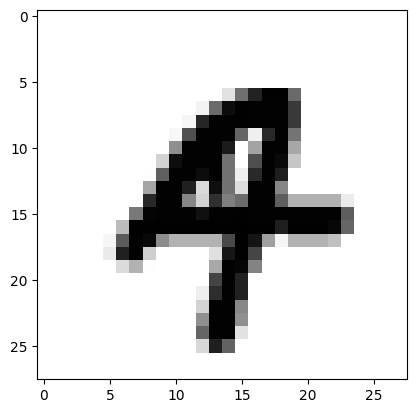

In [12]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')

In [13]:
print(imagens[0].shape) #para verificar as dimensões do tensor de cada imagem
print(etiquetas[0].shape) #para verificar as dimensões do tensor de cada etiqueta

torch.Size([1, 28, 28])
torch.Size([])


In [14]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.linear1 = nn.Linear(28*28, 128) # Camada de entrada, 784 neurônios que se ligam a 128
        self.linear2 = nn.Linear(128, 64)    # Camada interna 1, 128 neurônios que se ligam a 64
        self.linear3 = nn.Linear(64, 10)     # Camada interna 2, 64 neurônios que se ligam a 10
        # Para a camada de saída não é necessário definir nada pois só precisamos pegar o output da camada interna 2

    def forward(self, X):
        X = F.relu(self.linear1(X)) # Função de ativação da camada de entrada para a camada interna 1
        X = F.relu(self.linear2(X)) # Função de ativação da camada interna 1 para a camada interna 2
        X = self.linear3(X)         # Função de ativação da camada interna 2 para a camada de saída, nesse caso f(x) = x
        return F.log_softmax(X, dim=1) # Dados utilizados para calcular a perda

In [15]:
def treino(modelo, trainloader, device):
    
    otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5) # Define a política de atualização dos pesos e da bias
    inicio = time() # Timer para sabermos quanto tempo levou o treino
    
    criterio = nn.NLLLoss() # Definindo o critério para calcular a perda
    EPOCHS = 10 # Número de epochs que o algoritmo rodará
    modelo.train() # Ativando o modo de treinamento do modelo

    for epoch in range(EPOCHS):
        perda_acumulada = 0 # Inicialização da perda acumulada da epoch em questão
        
        for imagens, etiquetas in trainloader:
            
            # Convertendo as imagens para "vetores" de 28*28 casas para ficarem compatíveis com a camada de entrada
            imagens = imagens.view(imagens.shape[0], -1) 
            otimizador.zero_grad() # Zerando os gradientes por conta do ciclo anterior
            
            output = modelo(imagens.to(device)) # Colocando os dados no modelo
            perda_instantanea = criterio(output, etiquetas.to(device)) # Calculando a perda da epoch em questão
            
            perda_instantanea.backward() # Back propagation a partir da perda
            
            otimizador.step() # Atualizando os pesos e a bias
            
            perda_acumulada += perda_instantanea.item() # Atualização da perda acumulada
        
        else:
            print(f"Epoch {epoch+1} - Perda resultante: {perda_acumulada/len(trainloader)}")
    
    print(f"\nTempo de treino (em minutos) = {(time()-inicio)/60}")

In [16]:
def validacao(modelo, valloader, device):
    conta_corretas, conta_todas = 0, 0
    for imagens, etiquetas in valloader:
        for i in range(len(etiquetas)):
            img = imagens[i].view(1, 784)
            # Desativar o autograd para acelerar a validação. 
            # Grafos computacionais dinâmicos tem um custo alto de processamento
            with torch.no_grad():
                logps = modelo(img.to(device)) # output do modelo em escala logarítmica
            
            ps = torch.exp(logps) # converte output para escala normal (lembrando que é um tensor)
            probab = list(ps.cpu().numpy()[0])
            etiqueta_pred = probab.index(max(probab)) # converte o tensor em um número, no caso, o número que o modelo previu
            etiqueta_certa = etiquetas.numpy()[i]
            if(etiqueta_certa == etiqueta_pred): # compara a previsão com o valor correto
                conta_corretas += 1
            conta_todas += 1
            
    print(f"Total de imagens testadas = {conta_todas}")
    print(f"\nPrecisão do modelo = {conta_corretas*100/conta_todas}%")

In [17]:
modelo = Modelo() #inicia o modelo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)
treino(modelo, trainloader, device)

Epoch 1 - Perda resultante: 1.2064752695657044
Epoch 2 - Perda resultante: 0.3871276491422897
Epoch 3 - Perda resultante: 0.30993504065281546
Epoch 4 - Perda resultante: 0.2705581909113093
Epoch 5 - Perda resultante: 0.24108642444951828
Epoch 6 - Perda resultante: 0.21649129218114083
Epoch 7 - Perda resultante: 0.19573536870488797
Epoch 8 - Perda resultante: 0.17766017113516389
Epoch 9 - Perda resultante: 0.1619604129050332
Epoch 10 - Perda resultante: 0.14894733537258562

Tempo de treino (em minutos) = 2.6376109162966412


In [18]:
validacao(modelo, valloader, device)


Total de imagens testadas = 10000

Precisão do modelo = 95.76%
